# Clean Pro Agency — Analyse des rendez-vous

**Contexte.** Clean Pro Agency est une entreprise de nettoyage (voiture, canapé, tapis, matelas, vitres) qui prend ses rendez-vous en ligne. Chaque réservation génère une donnée transactionnelle exploitable pour piloter l'activité.

**Objectif.** Explorer ~18 mois de rendez-vous (jan. 2025 → juin 2026) pour répondre à :
- Quels services génèrent le plus de volume et de chiffre d'affaires ?
- Quand a-t-on de l'activité (saisonnalité, jours, créneaux) ?
- Qui sont les clients (zones géographiques, récurrence) ?
- Quelle est la satisfaction, et où sont les points d'amélioration ?

**Données.** 500 clients · 2 371 rendez-vous · 983 avis (jeu de données de démonstration).


## 1. Chargement des données


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

clients  = pd.read_csv('../data/clients.csv')
services = pd.read_csv('../data/services.csv')
rdv      = pd.read_csv('../data/rendez_vous.csv')
avis     = pd.read_csv('../data/avis.csv')

rdv.head()


   id  id_client  id_service            service   frequence  nbr_article    date_rdv heure_rdv  prix_total   statut
0   1        474           2   Nettoyage vitres  Ponctuelle            2  2025-01-01     15:00        50.0  Réalisé
1   2        103           1  Nettoyage voiture  Ponctuelle            1  2025-01-01     18:00        39.0  Réalisé
2   3        372           5  Nettoyage matelas   Mensuelle            1  2025-01-01     09:00        45.0  Réalisé
3   4        388           4    Nettoyage tapis  Ponctuelle            3  2025-01-01     14:00        87.0  Réalisé
4   5        309           3   Nettoyage canapé  Ponctuelle            1  2025-01-01     19:00        49.0   Annulé


## 2. Nettoyage & préparation
On type les dates, on extrait des variables utiles pour l'analyse (mois, heure, jour de la semaine) et on isole les rendez-vous **réalisés** (ceux qui comptent pour le chiffre d'affaires).


In [ ]:
rdv['date_rdv'] = pd.to_datetime(rdv['date_rdv'])
rdv['mois']= rdv['date_rdv'].dt.to_period('M').astype(str)
rdv['heure']= rdv['heure_rdv'].str.slice(0, 2).astype(int)
jours = {0:'Lundi',1:'Mardi',2:'Mercredi',3:'Jeudi',4:'Vendredi',5:'Samedi',6:'Dimanche'}
rdv['jour_sem'] = rdv['date_rdv'].dt.weekday.map(jours)

realise = rdv[rdv['statut'] == 'Réalisé'].copy()
print(rdv.shape, '->', realise.shape[0], 'rdv réalisés')


(2371, 13) -> 2139 rdv réalisés


## 3. Volume de rendez-vous par service

Le **nettoyage voiture** domine en volume, suivi du **canapé**. Les vitres et tapis restent des prestations d'appoint.


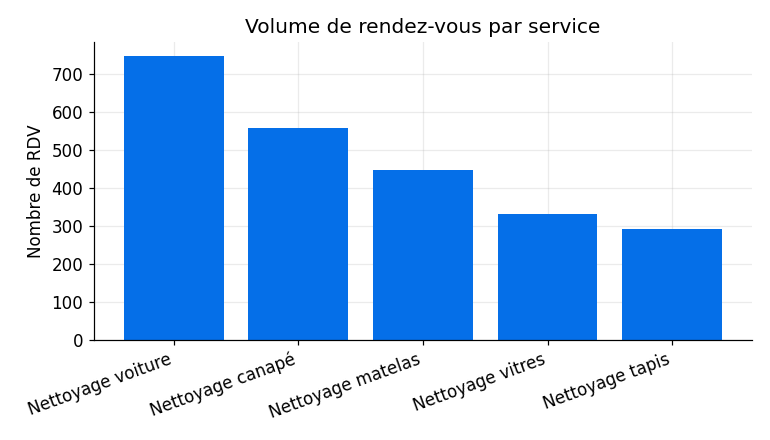

In [ ]:
vol = rdv['service'].value_counts()
vol.plot.bar(color='#056FE8', title='Volume de RDV par service')
plt.ylabel('Nombre de RDV'); plt.tight_layout(); plt.show()


## 4. Saisonnalité (évolution mensuelle)

L'activité suit une **saisonnalité nette** : creux marqué en **août**, pics au **printemps** et en **fin d'année** (avant les fêtes). Utile pour dimensionner les équipes et lancer des promotions en période creuse.


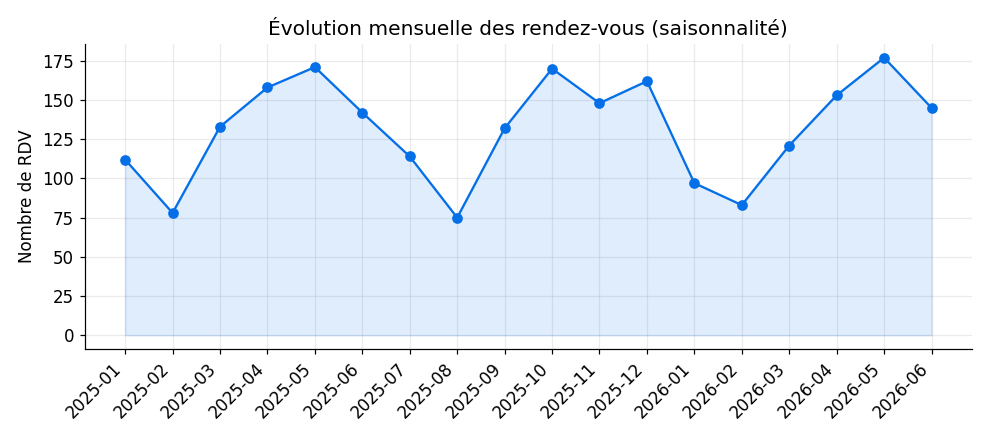

In [ ]:
rdv.groupby('mois').size().plot(marker='o', color='#056FE8', figsize=(9,4),
        title='Évolution mensuelle des rendez-vous')
plt.ylabel('Nombre de RDV'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()


## 5. Taux d'occupation par créneau horaire

La demande se concentre sur certains créneaux. Les heures les moins remplies sont des candidates idéales pour des **offres incitatives**.


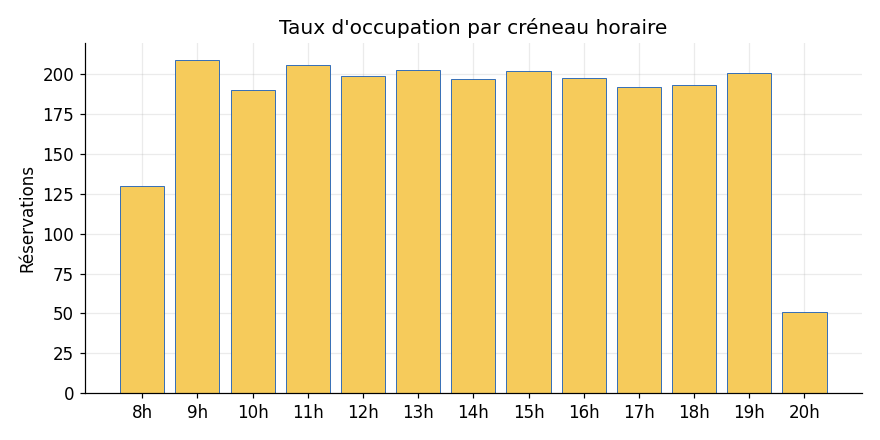

In [ ]:
rdv.groupby('heure').size().plot.bar(color='#F6CB5B', edgecolor='#004EBA',
        title="Taux d'occupation par créneau")
plt.ylabel('Réservations'); plt.tight_layout(); plt.show()


## 6. Charge par jour de la semaine

L'entreprise ouvre du **mardi au samedi**. Le **samedi** est le jour le plus chargé : c'est là qu'il faut le plus de personnel.


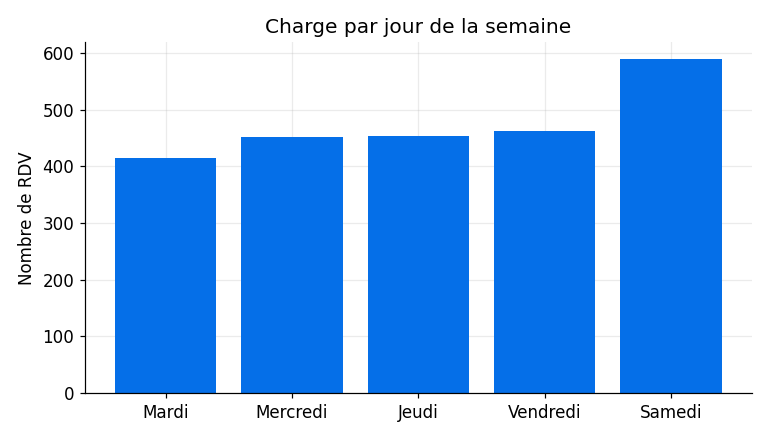

In [ ]:
ordre = ['Mardi','Mercredi','Jeudi','Vendredi','Samedi']
rdv['jour_sem'].value_counts().reindex(ordre).plot.bar(color='#056FE8',
        title='Charge par jour de la semaine')
plt.ylabel('Nombre de RDV'); plt.tight_layout(); plt.show()


## 7. Récurrence : répartition des fréquences

La majorité des rendez-vous sont **ponctuels**. Convertir une partie de ces clients vers des offres **mensuelles/trimestrielles** est un levier direct de revenus récurrents.


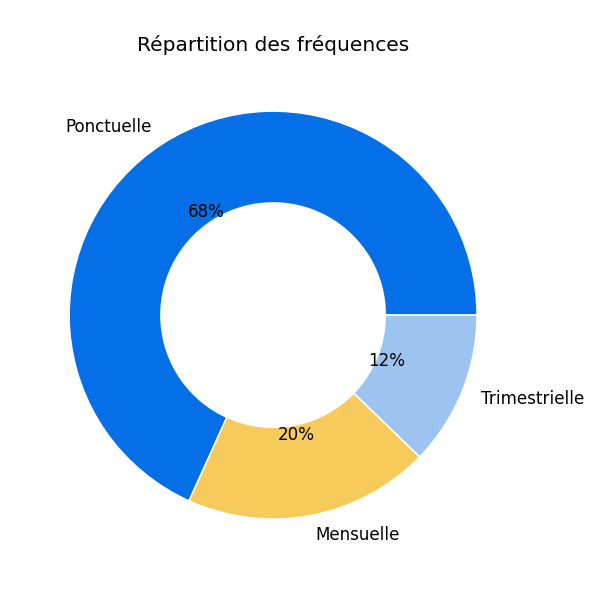

In [ ]:
rdv['frequence'].value_counts().plot.pie(autopct='%1.0f%%',
        colors=['#056FE8','#F6CB5B','#9DC3F0'], wedgeprops={'width':0.45})
plt.ylabel(''); plt.title('Répartition des fréquences'); plt.tight_layout(); plt.show()


## 8. Répartition géographique (top villes)

La clientèle est fortement concentrée sur **Ramonville-Saint-Agne et Toulouse**. Le marketing local peut cibler en priorité ces zones, et tester l'expansion sur les communes limitrophes.


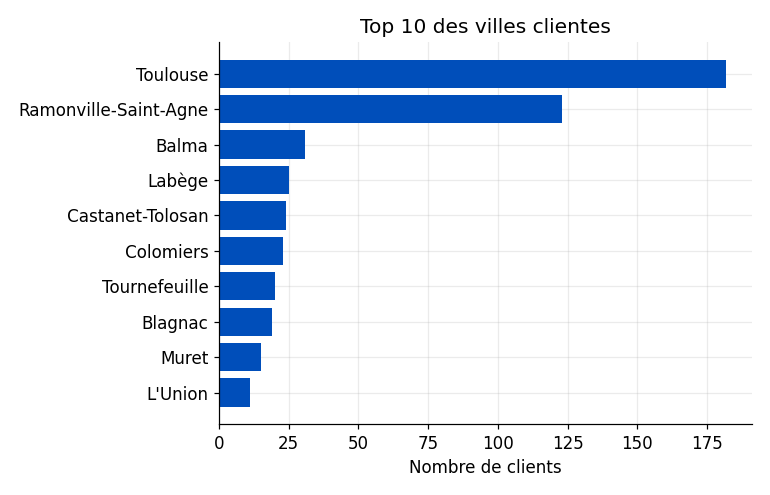

In [ ]:
clients['ville'].value_counts().head(10).sort_values().plot.barh(color='#004EBA',
        title='Top 10 des villes clientes')
plt.xlabel('Nombre de clients'); plt.tight_layout(); plt.show()


## 9. Chiffre d'affaires par service

Le **canapé** et la **voiture** portent l'essentiel du chiffre d'affaires (prix unitaire élevé × volume). Ce sont les prestations à prioriser dans la communication.


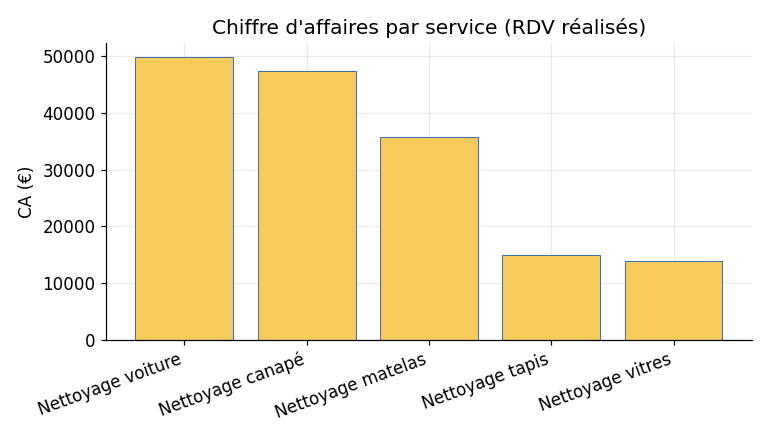

In [ ]:
realise.groupby('service')['prix_total'].sum().sort_values(ascending=False).plot.bar(
        color='#F6CB5B', edgecolor='#004EBA', title='CA par service (RDV réalisés)')
plt.ylabel('CA (€)'); plt.xticks(rotation=20); plt.tight_layout(); plt.show()


## 10. Satisfaction par service

La satisfaction moyenne est bonne (**~4,2/5**). Les écarts entre services indiquent où concentrer les efforts qualité.


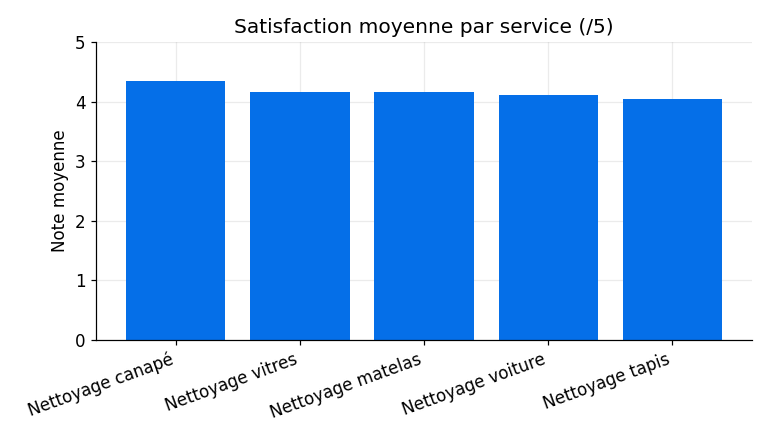

In [ ]:
av = avis.merge(services, on='id_service')
av.groupby('type_service')['note'].mean().sort_values(ascending=False).plot.bar(
        color='#056FE8', ylim=(0,5), title='Note moyenne par service (/5)')
plt.ylabel('Note /5'); plt.xticks(rotation=20); plt.tight_layout(); plt.show()


## 11. Synthèse des indicateurs (KPIs)


In [ ]:
kpis = {
  'RDV total': len(rdv), 'RDV réalisés': len(realise),
  'CA total (€)': round(realise['prix_total'].sum(), 2),
  'Panier moyen (€)': round(realise['prix_total'].mean(), 2),
  "Taux d'annulation (%)": round((rdv['statut']=='Annulé').mean()*100, 1),
  'Note moyenne /5': round(avis['note'].mean(), 2),
  'Clients actifs': rdv['id_client'].nunique(),
}
for k, v in kpis.items(): print(f'{k:>22} : {v}')


            nb_rdv : 2371
   nb_rdv_realises : 2139
          ca_total : 161831.0
      panier_moyen : 75.66
   taux_annulation : 9.8
      note_moyenne : 4.18
        nb_clients : 500
    clients_actifs : 490
           periode : 2025-01-01 → 2026-06-30


## 12. Conclusions & recommandations

**Ce que disent les données :**
1. **Voiture et canapé** sont le cœur du business (volume **et** chiffre d'affaires).
2. **Forte saisonnalité** : creux d'août, pics printemps / fin d'année.
3. Le **samedi** et certains créneaux concentrent la demande → tension sur les ressources.
4. **68 % de rendez-vous ponctuels** → gisement de fidélisation inexploité.
5. Clientèle **très locale** (Ramonville / Toulouse).

**Recommandations :**
- Lancer des **offres en période creuse** (août, mardi/mercredi, créneaux vides).
- Créer un **abonnement** (mensuel/trimestriel) pour convertir les ponctuels.
- **Renforcer l'équipe le samedi** et sur les créneaux saturés.
- Concentrer le **marketing local** sur Ramonville/Toulouse, puis tester les communes voisines.
- Suivre ces KPIs dans un **tableau de bord** (voir `analytics/dashboard/`).
